<a href="https://colab.research.google.com/github/Esrasilahsor/Sera-Gazi-Emisyon-Analiz/blob/main/Sera_gazi_emisyon_analiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Gerekli kütüphaneleri entegre ettim
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Veriyi API kullanarak sisteme entegre ettim
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 1990 yılından sonra Türkiye'deki CO2 ve toplam sera gazı emisyonuna baktım
tr = df[df['country'] == 'Turkey']
tr_yakin = tr[tr['year'] >= 1990]
tr_yakin[['year', 'co2', 'total_ghg']].head()

,year,co2,total_ghg
46215,1990,154.572,233.442
46216,1991,161.126,231.524
46217,1992,167.234,239.700
46218,1993,174.291,256.232
46219,1994,170.592,240.383


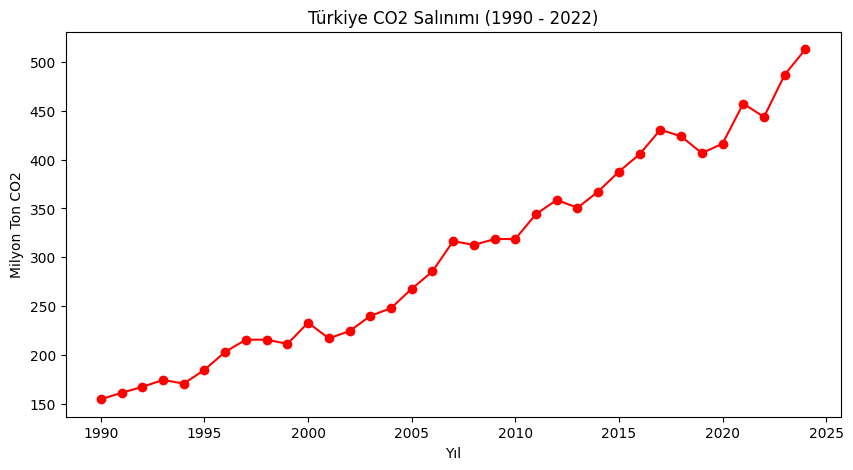

In [ ]:
# Elde olan verileri görselleştirdim
plt.figure(figsize=(10, 5))

# X ekseni= yıl(year) Y ekseni= CO2 miktarı(co2)
plt.plot(tr_yakin['year'], tr_yakin['co2'], color='red', marker='o')
plt.title('Türkiye CO2 Salınımı (1990 - 2022)')
plt.xlabel('Yıl')
plt.ylabel('Milyon Ton CO2')
plt.show()

***Analiz:***

Yapılan veri analizine göre, Türkiye’nin 1990 yılından günümüze uzanan karbon salınımı CO2 düzenli bir artış göstermektedir. Bu grafik, ülkemizin ekonomik büyüme ve sanayileşme süreçlerinde enerji ihtiyacını büyük oranda fosil yakıtlardan karşıladığını kanıtlamaktadır. Özellikle 2000'li yıllardan sonra nüfusun artması ve enerji tüketiminin yoğunlaşmasıyla birlikte emisyon miktarındaki yükselişin ivme kazandığı görülmektedir. Bu durum, kalkınma hedefleri ile çevresel sürdürülebilirlik arasındaki dengenin emisyon artışı yönünde değiştiğini ortaya koymaktadır.

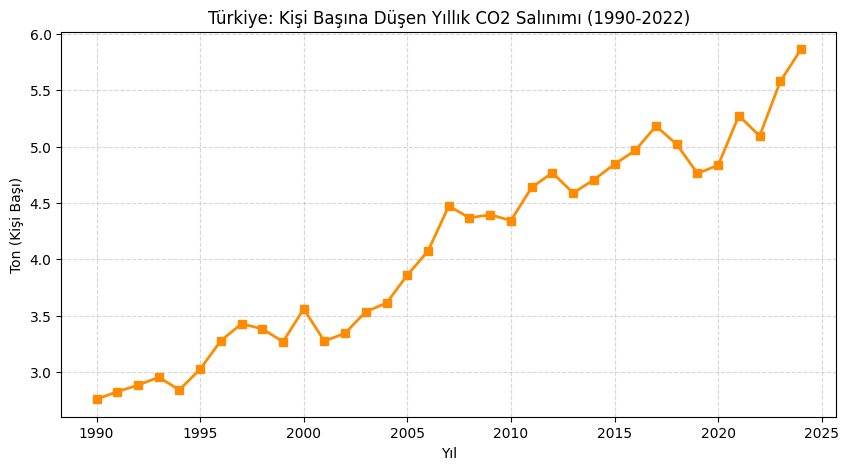

In [ ]:
#Kişi başına düşen karbon salınımını daha iyi anlayabilmek için görselleştirdim
plt.figure(figsize=(10, 5))

# X ekseni= yıl(year) Y ekseni= Kişi başına düşen karbon salınımı(co2_per_capita)
plt.plot(tr_yakin['year'], tr_yakin['co2_per_capita'], color='darkorange', linewidth=2, marker='s')
plt.title('Türkiye: Kişi Başına Düşen Yıllık CO2 Salınımı (1990-2022)', fontsize=12)
plt.xlabel('Yıl')
plt.ylabel('Ton (Kişi Başı)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

***Analiz:***

Yapılan analizde, Türkiye'nin toplam emisyon artışının yanı sıra birey başına düşen CO2 miktarının da zamanla yükseldiği görülmektedir.
Bu grafik, sadece nüfus artışının değil, aynı zamanda değişen yaşam standartlarının ve bireysel enerji tüketim alışkanlıklarının da çevresel etkisini
ortaya koymaktadır. Kişi başına düşen salınımın artması, her bir bireyin atmosfere bıraktığı karbon yükünün ağırlaştığını ve sürdürülebilir yaşam
pratiklerinin (enerji tasarrufu, bilinçli tüketim vb.) yaygınlaştırılmasının gerekliliğini belgelemektedir.

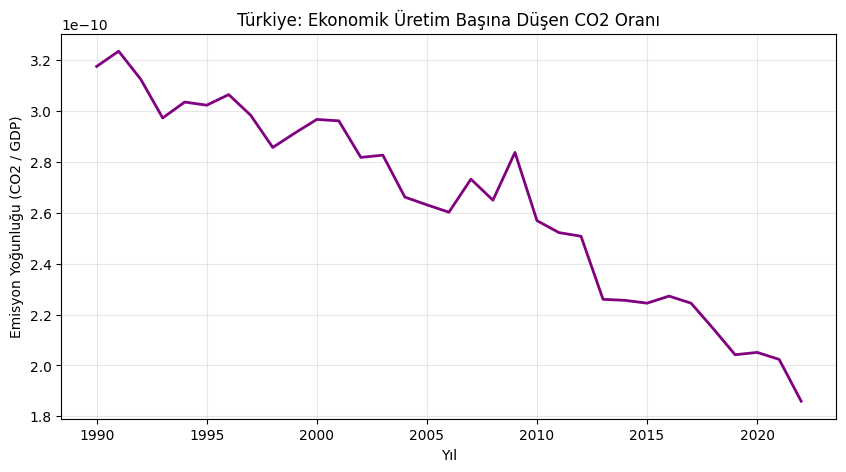

In [ ]:
# Orijinal Türkiye tablosunu bozmamak için bu verilerin bir kopyasını oluşturup yeni bir tablo haline getirdim.
ekonomi_df = tr_yakin[tr_yakin['gdp'] > 0].copy()

# Havaya salınan toplam karbon miktarını (co2), o yıl üretilen toplam ekonomik değere (gdp) böldüm.
ekonomi_df['emisyon_yogunlugu'] = ekonomi_df['co2'] / ekonomi_df['gdp']

#Elde ettiğim verileri görselleştirdim.
plt.figure(figsize=(10, 5))
plt.plot(ekonomi_df['year'], ekonomi_df['emisyon_yogunlugu'], color='purple', linewidth=2)
plt.title('Türkiye: Ekonomik Üretim Başına Düşen CO2 Oranı', fontsize=12)
plt.xlabel('Yıl')
plt.ylabel('Emisyon Yoğunluğu (CO2 / GDP)')
plt.grid(True, alpha=0.3)
plt.show()

***Analiz:***

Ekonomi ile çevre arasındaki ilişkiyi inceleyen bu analizde, üretilen her birim ekonomik değer (GSYİH) başına salınan karbon miktarı değerlendirilmiştir.Grafikteki eğilim, Türkiye'nin ekonomik büyüme sağlarken teknolojik gelişimle birlikte kirlilik oranını ne kadar dengeleyebildiğini göstermektedir. Bu oran düşüş eğilimindeyse, üretim süreçlerinin daha "temiz" teknolojilere evrildiği ve birim üretim başına doğaya verilen zararın azaldığı sonucuna varılabilir. Bu veriler, "Yeşil Ekonomi"ye geçiş sürecindeki performansımızı ölçmek açısından önemli bir göstergedir.